正在读取 Basis 3 的实验数据...
✅ 成功读取渗透率输入数据，形状: (100, 1, 128, 128)
✅ 带比例尺的成品图已保存到: /workspace/SURF-2026-me/outputs/my_final_comparison3_with_bar.png


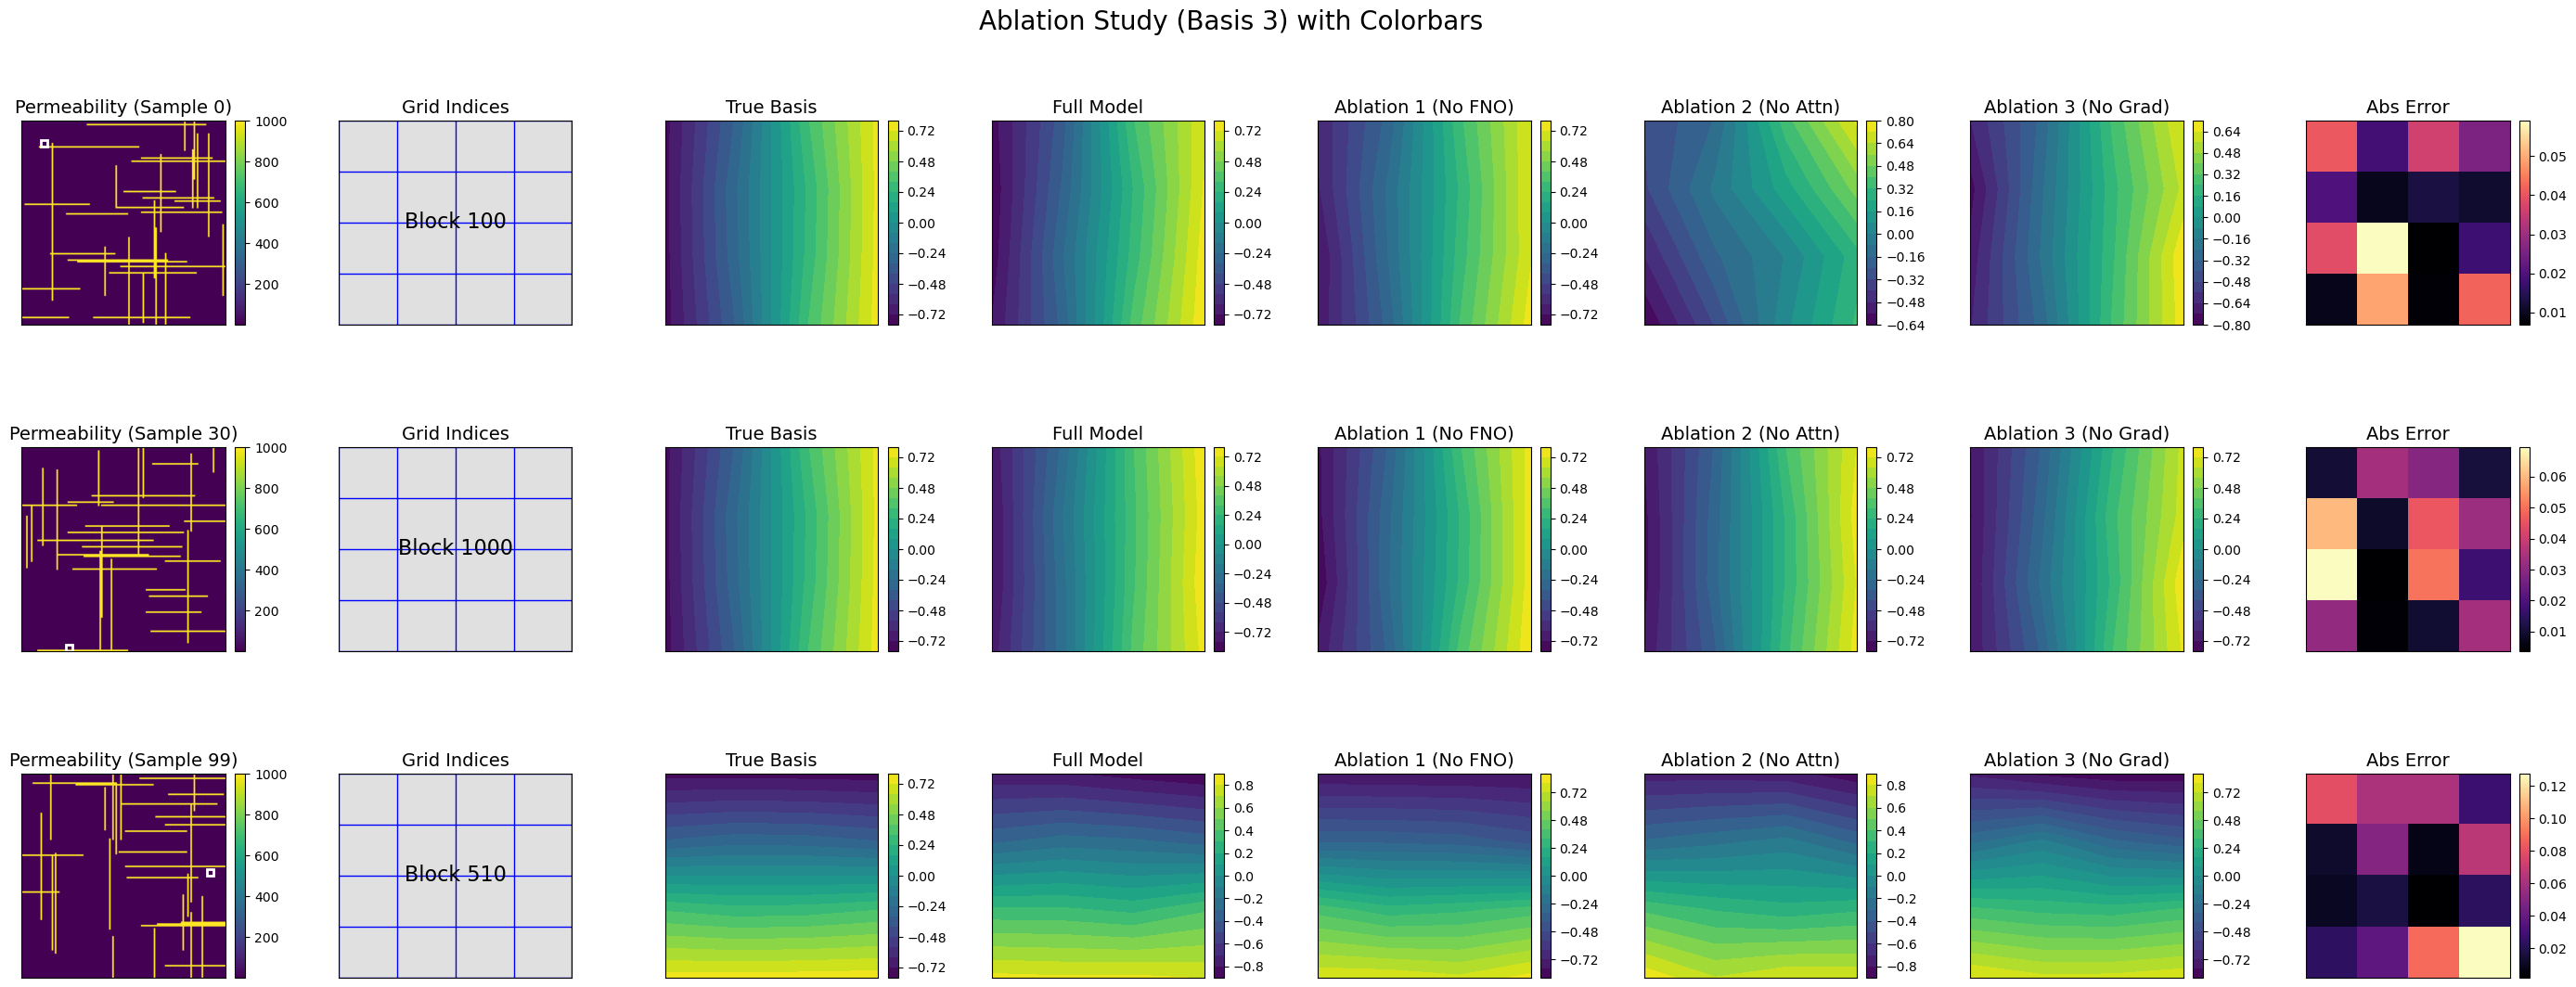

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Rectangle

# ============================================================
# 👇 第一步：路径设置
# ============================================================
full_path = Path("/outputs/teaching_single_basis3/basis_03/predictions_basis_03.npz")
ab1_path = Path("/outputs/teaching_single_basis3_no_fno/basis_03/predictions_basis_03.npz")
ab2_path = Path("/outputs/teaching_single_basis3_no_attention/basis_03/predictions_basis_03.npz")
ab3_path = Path("/outputs/teaching_single_basis3_no_gradient/basis_03/predictions_basis_03.npz")

print("正在读取 Basis 3 的实验数据...")
y_true = np.load(full_path)['y_true']
y_full = np.load(full_path)['y_pred']
y_ab1 = np.load(ab1_path)['y_pred']
y_ab2 = np.load(ab2_path)['y_pred']
y_ab3 = np.load(ab3_path)['y_pred']

# ============================================================
# 👇 读取对应的渗透率输入数据 (X)
# ============================================================
x_path = Path("/outputs/teaching_single_basis3/basis_03/x_data.npz")
if x_path.exists():
    x_test = np.load(x_path)['x_test']
    print(f"✅ 成功读取渗透率输入数据，形状: {x_test.shape}")
else:
    print(f"⚠️ 警告：未找到渗透率数据文件 {x_path}，将使用随机占位图！")
    x_test = np.random.rand(100, 1, 128, 128) 

# ============================================================
# 👇 第二步：核心切块工具
# ============================================================
def coarse_element_patch(field, coarse_elem_idx, local_shape=(4, 4), one_based=True):
    arr = field.reshape(32, 32, 4, 4) 
    if one_based:
        idx = coarse_elem_idx - 1
    else:
        idx = coarse_elem_idx
    row = idx // 32
    col = idx % 32
    return arr[row, col]

# ============================================================
# 👇 第三步：差异化设计
# ============================================================
sample_idx = [0, 30, 99]
blocks_to_show = [100, 1000, 510]

# ============================================================
# 👇 第四步：超清画图 (带比例尺版本)
# ============================================================
fig, axes = plt.subplots(nrows=3, ncols=8, figsize=(35, 12)) # 加宽画布给色条留空间
plt.subplots_adjust(wspace=0.4, hspace=0.6) # 加大列间距

# 修改后的画图函数：返回绘图对象以便加色条
def draw_contour(ax, data, title, block_idx):
    patch = coarse_element_patch(data, coarse_elem_idx=block_idx)
    # 返回 contour 对象
    contour = ax.contourf(patch, levels=20, cmap='viridis')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14)
    return contour

# 开始循环画图
for row in range(3):
    i = sample_idx[row]
    current_block = blocks_to_show[row]
    
    # ---------------- 第 0 列：渗透率场 ----------------
    ax0 = axes[row, 0]
    kappa_img = x_test[i, 0, :, :]  
    im0 = ax0.imshow(kappa_img, cmap='viridis') # 返回对象
    
    # 画白框
    idx0 = current_block - 1
    start_row = (idx0 // 32) * 4
    start_col = (idx0 % 32) * 4
    rect = Rectangle((start_col - 0.5, start_row - 0.5), 4, 4, linewidth=2, edgecolor='white', facecolor='none')
    ax0.add_patch(rect)
    ax0.set_xticks([])
    ax0.set_yticks([])
    ax0.set_title(f"Permeability (Sample {i})", fontsize=14)
    # 给渗透率加上色条
    plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)
    
    # ---------------- 第 1 列：网格指示图 ----------------
    ax1 = axes[row, 1]
    ax1.set_facecolor('#e0e0e0')
    for x in range(5):
        ax1.axhline(x, color='blue', lw=1)
        ax1.axvline(x, color='blue', lw=1)
    ax1.text(2, 2, f"Block {current_block}", ha='center', va='center', fontsize=16, color='black')
    ax1.set_xlim(0, 4); ax1.set_ylim(4, 0)
    ax1.set_xticks([]); ax1.set_yticks([])
    ax1.set_title(f"Grid Indices", fontsize=14)

    # ---------------- 列 2~6：基函数对比 ----------------
    # 接收画图返回的 contour 对象
    c_true = draw_contour(axes[row, 2], y_true[i], f"True Basis", current_block)
    c_full = draw_contour(axes[row, 3], y_full[i], "Full Model", current_block)
    c_ab1  = draw_contour(axes[row, 4], y_ab1[i], "Ablation 1 (No FNO)", current_block)
    c_ab2  = draw_contour(axes[row, 5], y_ab2[i], "Ablation 2 (No Attn)", current_block)
    c_ab3  = draw_contour(axes[row, 6], y_ab3[i], "Ablation 3 (No Grad)", current_block)
    
    # 给它们加上色条 (fraction控制高度, pad控制离图的距离)
    plt.colorbar(c_true, ax=axes[row, 2], fraction=0.046, pad=0.04)
    plt.colorbar(c_full, ax=axes[row, 3], fraction=0.046, pad=0.04)
    plt.colorbar(c_ab1,  ax=axes[row, 4], fraction=0.046, pad=0.04)
    plt.colorbar(c_ab2,  ax=axes[row, 5], fraction=0.046, pad=0.04)
    plt.colorbar(c_ab3,  ax=axes[row, 6], fraction=0.046, pad=0.04)
    
    # ---------------- 列 7：误差图 ----------------
    error = np.abs(y_full[i] - y_true[i])
    patch_error = coarse_element_patch(error, coarse_elem_idx=current_block)
    im_err = axes[row, 7].imshow(patch_error, cmap='magma') # 返回对象
    axes[row, 7].set_xticks([])
    axes[row, 7].set_yticks([])
    axes[row, 7].set_title(f"Abs Error", fontsize=14)
    # 给误差图加上色条
    plt.colorbar(im_err, ax=axes[row, 7], fraction=0.046, pad=0.04)

fig.suptitle("Ablation Study (Basis 3) with Colorbars", fontsize=20)

# 保存结果
save_path = Path("/workspace/SURF-2026-me/outputs/my_final_comparison3_with_bar.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"✅ 带比例尺的成品图已保存到: {save_path}")
plt.show()